# Peak Finding Challenge

In this in-class activity, you will adjust parameters on SciPy's automated "find_peaks" function to adequately identify peaks in a set of IR spectra. Polymer datasets are taken from O. Villegas-Camacho et. al. "FTIR-Plastics: A Fourier Transform Infrared Spectroscopy dataset for the six most prevalent inducstrial plastic polymers", *Data in Brief* 55, 110612 (2024) https://doi.org/10.1016/j.dib.2024.110612



In [1]:
# the standard cell
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
!git clone https://github.com/cbishop4/MSE7530.git

Cloning into 'MSE7530'...
remote: Enumerating objects: 619, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 619 (delta 53), reused 5 (delta 5), pack-reused 494 (from 2)
Receiving objects: 100% (619/619), 77.91 MiB | 21.31 MiB/s, done.
Resolving deltas: 100% (215/215), done.


### f-strings  
I will use [f-strings](https://www.geeksforgeeks.org/python/formatted-string-literals-f-strings-python/) often in this course to **print information** or **construct file-paths**. The basic construction of an f-string is as follows:  


```
block_count = 50
print(f'The variable I defined is equal to {block_count}')
```
The printed output would then be:
```
The variable I defined is equal to 50
```
The main features of the f-string are that it starts with an f directly before the string (no space), and any variables you want to print out or add to your string should be included in curly braces {} within the string.  
Below I am defining the data-path where the files that we will use are held. I will later use a lot of f-strings that begin with {dpath} to short-cut in this directory.



In [3]:
dpath = '/content/MSE7530/sampledata/plastics/known/'

### Pandas  
We will use Pandas often in this class. Its main strength is the two-dimensional data structure called a **DataFrame**, which is a table with rows and columns. The particularly useful functions we will use a lot is "read_csv", "read_excel", etc., which load a file into your notebook and create a dataframe.  Rather than have me reinvent the wheel in this notebook, here are a few resources you can use to become familiar with dataframes:  
[Pandas in 10 minutes](https://pandas.pydata.org/docs/user_guide/10min.html)  
[Getting Started](https://pandas.pydata.org/docs/getting_started/index.html)  
[User Guide](https://pandas.pydata.org/docs/user_guide/index.html#user-guide)  
Click around these websites to learn more - there are a lot of user guides and tutorials.


## Loading data with Pandas & Plotting

Here we will load data from 3 of the HDPE (high-density polyethylene) spectra into **DataFrames**. There are certain parameters, such as "skiprows" and "header", that I have filled in by visually inspecting the csv files. These account for where the data starts after the metadata and whether or not there are labels on the columns, respectively.

In [4]:
HDPE1 = pd.read_csv(filepath_or_buffer=f'{dpath}HDPE1.csv',skiprows=15,header=None, names=['wn','I'])
# this could be automated but I will do explicitly for now
HDPE2 = pd.read_csv(filepath_or_buffer=f'{dpath}HDPE2.csv',skiprows=15,header=None, names=['wn','I'])
HDPE3 = pd.read_csv(filepath_or_buffer=f'{dpath}HDPE3.csv',skiprows=15,header=None, names=['wn','I'])
# showing the dataframe
HDPE3

,wn,I
0,399.1927,81.9295
1,400.1569,83.1489
2,401.1211,84.2518
3,402.0854,85.0501
4,403.0496,85.5347
...,...,...
3731,3996.7476,104.1820
3732,3997.7119,104.2250
3733,3998.6760,104.2630
3734,3999.6404,104.2910


We can plot data from this dataset by selecting the columns. Note that I have performed the conversion from transmission $T$ to absorbance $A$ by the formula  
$A = log_{10}(\frac{1}{T})$

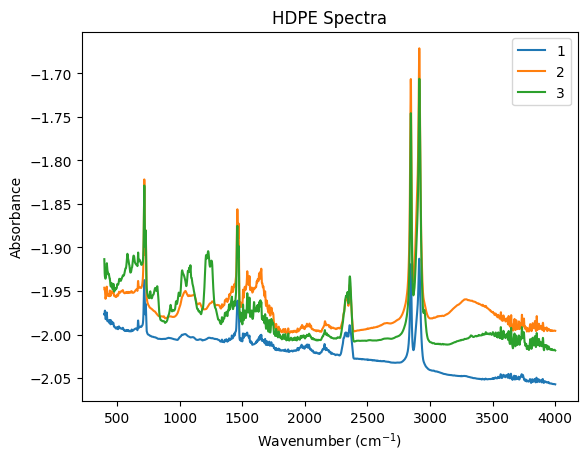

In [5]:
fig, ax = plt.subplots()
ax.plot(HDPE1['wn'],np.log10(1/HDPE1['I']),label='1')
ax.plot(HDPE2['wn'],np.log10(1/HDPE2['I']),label='2')
ax.plot(HDPE3['wn'],np.log10(1/HDPE3['I']),label='3')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Absorbance')
ax.set_title('HDPE Spectra')
ax.legend()

There are 6 polymers in this database, and we will want to sort them. This huge dataset has 500 spectra for each type of polymer, more than any person could get through. We will plot the 6 first so that we can discuss how the data looks visually before proceeding. To generate this code, I began by typing the pnames line and the fig, ax line. After that, Gemini suggested an autocomplete which I took and then tweaked (for example, it labeled the Y axes as transission'). Therefore, you will see that it specified the path differently than I usually do with f-strings, and taught me a new notation to specify axes to plot on.

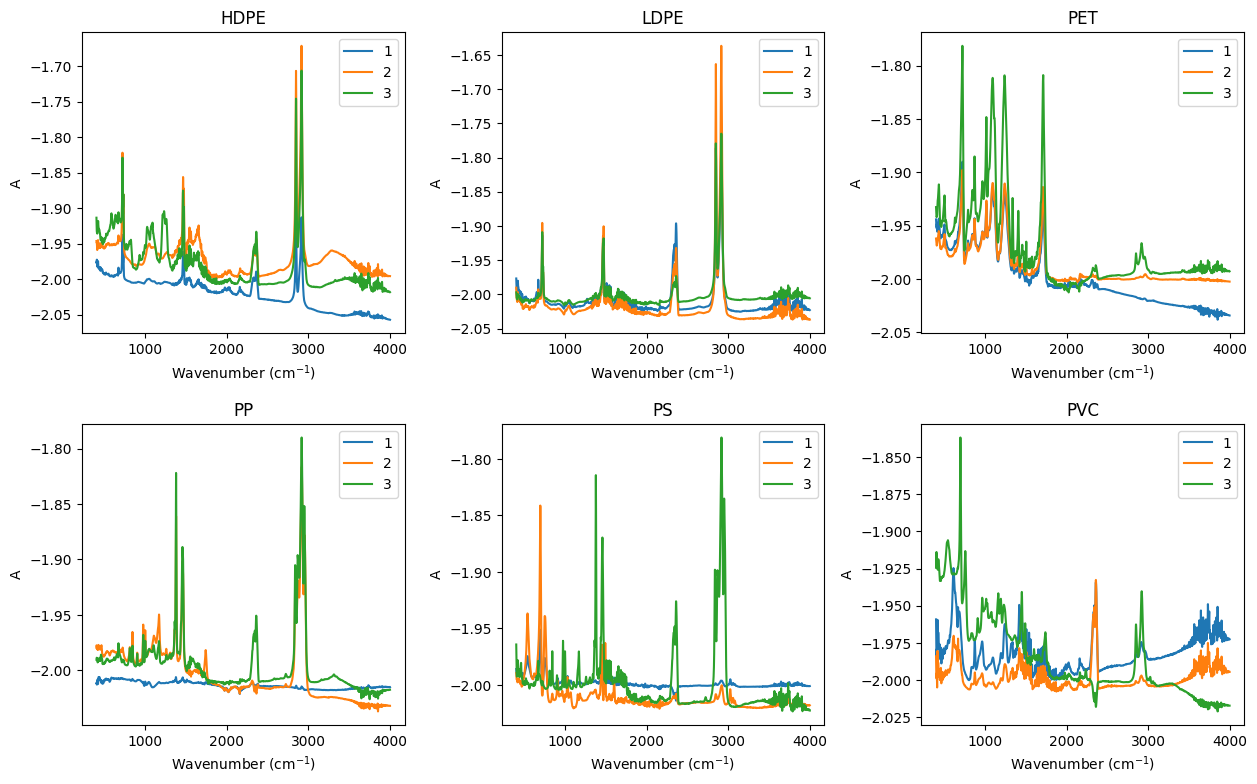

In [6]:
pnames = ['HDPE', 'LDPE', 'PET', 'PP', 'PS', 'PVC']
fig, ax = plt.subplots(2,3, figsize=(15,9))
plt.subplots_adjust(hspace=0.3,wspace=0.3)
l=0
for p in pnames:
  for i in range(3):
    df = pd.read_csv(os.path.join(dpath, p+str(i+1)+'.csv'),skiprows=15,header=None, names=['wn','I'])
    ax[l//3,l%3].plot(df['wn'],np.log10(1/df['I']),label=(i+1))
  ax[l//3,l%3].set_title(p)
  l += 1

for a in ax.reshape(-1):
  a.set_xlabel('Wavenumber (cm$^{-1}$)')
  a.set_ylabel('A')
  a.legend()

Initially, this dataset looks overwhelming (this is my gut reaction). <font color='blue'>Visually, can you see any common features for certain polymers? Which look more reproducible than others?

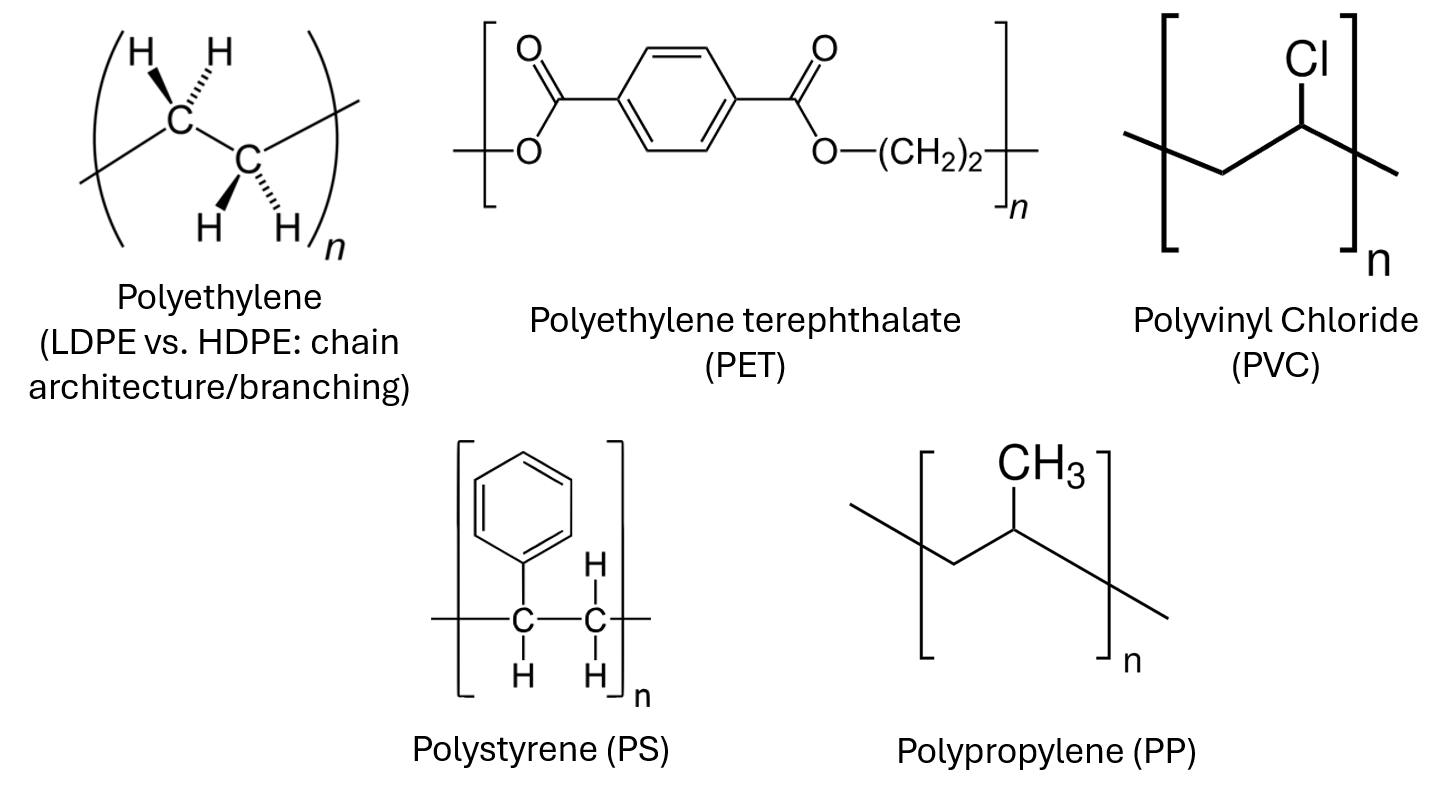

<font size=4> Discuss: Why is the fingerprint region so important in these different polymers? Which are the hardest spectra to distinguish between? What can you find in their chemical structures that contribute to why this is?